In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor

def rmse(target,prediction):
    return(np.sqrt(((target - prediction)**2).sum()/len(target)))



In [2]:
### Make some data
np.random.seed(123)
XX1 = np.random.randn(1000)
XX2 = np.random.randn(1000)
XX = np.array([XX1,XX2]).T
YY = np.sin(XX1)*np.exp(-np.abs(XX2))+np.random.randn(1000)

### I'm not normalizing here just for sake of example. For your assignment, you should!
ntrain = 800
x_train = XX[:ntrain]
y_train = YY[:ntrain]
x_test = XX[ntrain:]
y_test = YY[ntrain:]


### And some unknown testing data
### Note, just like the assignment, you won't have y values!
x_unknown = np.array([np.random.randn(50),np.random.randn(50)]).T

In [3]:
num_models = 10 #number of models to build for the ensemble
min_nhn = 1 #minimum number of hidden neurons to loop through (nhn = 'number hidden neurons')
max_nhn = 12 #maximum number of hidden neurons to loop through
max_hidden_layers = 1 #maximum number of hidden layers to loop through (nhl = 'number hidden layers')
batch_size = 32
solver = 'adam' #use stochastic gradient descent as an optimization method (weight updating algorithm)
activation = 'relu'
learning_rate_init = 0.001
max_iter = 1500 #max number of epochs to run
early_stopping = True #True = stop early if validation error begins to rise
validation_fraction = 0.2 #fraction of training data to use as validation


y_out_all_nhn = []
y_out_ensemble = []
RMSE_ensemble = [] #RMSE for each model in the ensemble
RMSE_ensemble_cumsum = [] #RMSE of the cumulative saltation for each model
nhn_best = []
nhl_best = []
all_models = []    ### NEW

for model_num in range(num_models): #for each model in the ensemble
    
    print('Model Number: ' + str(model_num))
    
    RMSE = []
    y_out_all_nhn = []
    nhn = []
    nhl = []
    models = []   ### NEW
    
    for num_hidden_layers in range(1,max_hidden_layers+1):
    
        print('\t # Hidden Layers = ' + str(num_hidden_layers))
    
        for num_hidden_neurons in range(min_nhn,max_nhn+1): #for each number of hidden neurons

            print('\t\t # hidden neurons = ' + str(num_hidden_neurons))
            
            hidden_layer_sizes = (num_hidden_neurons,num_hidden_layers)
            model = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes, 
                                 verbose=False,
                                 max_iter=max_iter, 
                                 early_stopping = early_stopping,
                                 validation_fraction = validation_fraction,
                                 batch_size = batch_size,
                                 solver = solver,
                                 activation = activation,
                                 learning_rate_init = learning_rate_init)

            model.fit(x_train,y_train) #train the model

            y_out_this_nhn = model.predict(x_test) #model prediction for this number of hidden neurons (nhn)
            y_out_all_nhn.append(y_out_this_nhn) #store all models -- will select best one best on RMSE

            RMSE.append(rmse(y_test,y_out_this_nhn)) #RMSE between cumulative curves
            
            nhn.append(num_hidden_neurons)
            nhl.append(num_hidden_layers)
            
            models.append(model) ### NEW
        
    indBest = RMSE.index(np.min(RMSE)) #index of model with lowest RMSE
    RMSE_ensemble.append(np.min(RMSE))
    nhn_best.append(nhn[indBest])
    nhl_best.append(nhl[indBest])
    all_models.append(models[indBest]) ### NEW
    #nhn_best.append(indBest+1) #the number of hidden neurons that achieved best model performance of this model iteration
    y_out_ensemble.append(y_out_all_nhn[indBest])
    
    print('\t BEST: ' + str(nhl_best[model_num]) + ' hidden layers, '+ str(nhn_best[model_num]) + ' hidden neurons')
    
y_out_ensemble_mean = np.mean(y_out_ensemble,axis=0)
RMSE_ensemble_mean = rmse(y_out_ensemble_mean,y_test)

Model Number: 0
	 # Hidden Layers = 1
		 # hidden neurons = 1
		 # hidden neurons = 2
		 # hidden neurons = 3
		 # hidden neurons = 4
		 # hidden neurons = 5
		 # hidden neurons = 6
		 # hidden neurons = 7
		 # hidden neurons = 8
		 # hidden neurons = 9
		 # hidden neurons = 10
		 # hidden neurons = 11
		 # hidden neurons = 12
	 BEST: 1 hidden layers, 12 hidden neurons
Model Number: 1
	 # Hidden Layers = 1
		 # hidden neurons = 1
		 # hidden neurons = 2
		 # hidden neurons = 3
		 # hidden neurons = 4
		 # hidden neurons = 5
		 # hidden neurons = 6
		 # hidden neurons = 7
		 # hidden neurons = 8
		 # hidden neurons = 9
		 # hidden neurons = 10
		 # hidden neurons = 11
		 # hidden neurons = 12
	 BEST: 1 hidden layers, 12 hidden neurons
Model Number: 2
	 # Hidden Layers = 1
		 # hidden neurons = 1
		 # hidden neurons = 2
		 # hidden neurons = 3
		 # hidden neurons = 4
		 # hidden neurons = 5
		 # hidden neurons = 6
		 # hidden neurons = 7
		 # hidden neurons = 8
		 # hidden neurons = 9
		

In [4]:
### Now, we have a list of the best-performing models.
### First thing to do is save them. 
### This is really important if you're working with a partner & in the interest of making results repeatable 
### and just so you don't have to run the above code all the time
pickle.dump(all_models,open("my_models.p","wb"))

In [5]:
### Now at any point in the future, you can open these models again and they'll be exactly as they were. 
### Let's try that here:
loaded_models = pickle.load(open("my_models.p","rb"))

In [6]:
predicted_output = np.array([mod.predict(x_unknown) for mod in loaded_models])

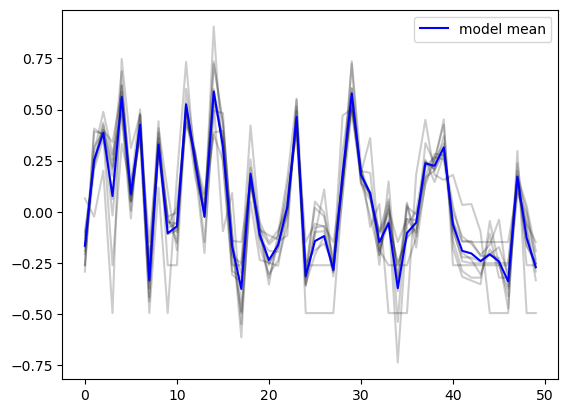

In [7]:
plt.plot(predicted_output.T,c="k",alpha=0.2)
plt.plot(predicted_output.mean(axis=0),c="b",label="model mean")
plt.legend()

In [8]:
### Finally, save the output!
np.savetxt("LASTNAME.csv", predicted_output.mean(axis=0), delimiter=",")